# **Image Stitching**
## !! CHANGE INPUT IMAGES HERE !!
## v v v v v v v v v v v v v v v v v

In [486]:
image1Location = 'leftImage.png'
image2Location = 'rightImage.png'

## ^^^^^^^^^^^^^^^^^^

Import libraries

In [487]:
from skimage.feature import corner_harris, corner_peaks
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

Image prep

In [488]:
# function: make image gray
def makeGray(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    return gray

In [489]:
#grabbing the images based on locations provide ^^^
image1 = cv2.imread(image1Location)
image2 = cv2.imread(image2Location)

#gray version of each image
gray1 = makeGray(image1)
gray2 = makeGray(image2)

## 1. Harris Corner Detection
### **Function: harrisCornerDetection**

Does Harris Corner Detection on inputted image
Outputs keypoints and corner_harris response

In [490]:
def harrisCornerDetection(imgGray):
    response = corner_harris(imgGray)
    coords = corner_peaks(
        response,
        min_distance = 8,
        num_peaks = 1000,
        threshold_rel=0.0001
    )

    keypoints = np.array([[c[1], c[0]] for c in coords], dtype=np.float32)
    return keypoints, response

In [491]:
keypoints1, harrisResponse1 = harrisCornerDetection(gray1)
keypoints2, harrisResponse2 = harrisCornerDetection(gray2)

### **Function: visualHarrisCornerDetection**

Makes visual of keypoints on the image
For checking whether working & report

In [492]:
def visualHarrisCornerDetection(img, keypoints):
    vis = img.copy()
    if len(vis.shape) == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2RGB)

    for x, y in keypoints.astype(int):
        cv2.circle(vis, (x, y), 3, (255, 0, 0), -1)

    plt.figure(figsize=(8, 6))
    plt.imshow(vis, cmap="gray")
    plt.title("Keypoints")
    plt.axis("off")
    plt.show()

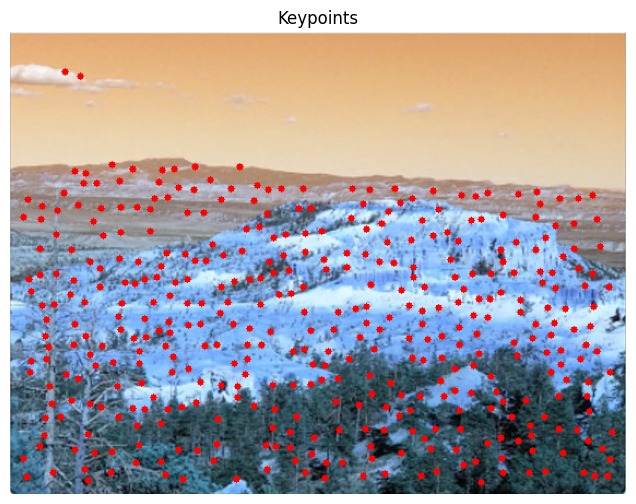

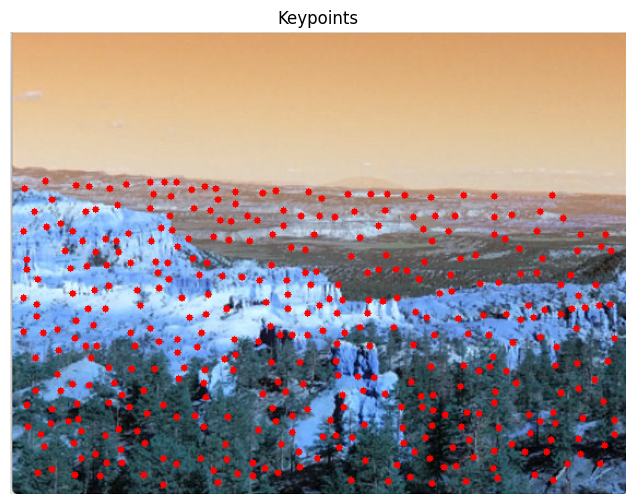

In [493]:
visualHarrisCornerDetection(image1, keypoints1)
visualHarrisCornerDetection(image2, keypoints2)

### **Function: patches**

Gets patch descriptors for the keypoints

In [494]:
def patches(imgGray, keypoints):
    patchSize = 11 #MUST BE AN ODD NUMBER
    half = patchSize // 2

    h, w = imgGray.shape
    valid_kps, descs = [], []

    for r, c in keypoints:
        if r - half < 0 or r + half + 1 > h or c - half < 0 or c + half + 1 > w:
            continue
        patch = imgGray[
            int(r - half):int(r + half + 1),
            int(c - half):int(c + half + 1)].copy()
        patch = patch.astype(np.float32)
        #zero-mean + unit-variance normalisation
        std = patch.std()
        if std < 1e-6:
            continue
        patch = (patch - patch.mean()) / std
        valid_kps.append((r, c))
        descs.append(patch.flatten())

    return np.array(valid_kps), np.array(descs, dtype=np.float32)

## 2. Sift (Optional)
### **Function: sift**
Gets SIFT descriptors for the keypoints

In [495]:
def sift(imgGray, keypoints):
    size = 16 #change if you want
    
    #change to uint8
    #(OpenCV SIFT didn't like the previous format)
    if imgGray.dtype != np.uint8:
        if imgGray.max() <= 1.0:
            imgGray = (imgGray * 255).astype(np.uint8)
        else:
            imgGray = np.clip(imgGray, 0, 255).astype(np.uint8)

    sift = cv2.SIFT_create()

    cv2_keypoints = [
        cv2.KeyPoint(float(x), float(y), size)
        for x, y in keypoints
    ]

    cv2_keypoints, descriptors = sift.compute(imgGray, cv2_keypoints)

    if descriptors is None or len(cv2_keypoints) == 0:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 128), dtype=np.float32)

    final_keypoints = np.array([[kp.pt[0], kp.pt[1]] for kp in cv2_keypoints], dtype=np.float32)
    return final_keypoints, descriptors.astype(np.float32)

## !! Do you want to use SIFT? !!
## v v v v v v v v v v v v v v v v v

In [496]:
#change to True or False
useSift = True

## ^^^^^^^^^^^^^^^^^^

In [497]:
if useSift:
    kp1desc, desc1 = sift(gray1, keypoints1)
    kp2desc, desc2 = sift(gray2, keypoints2)
else:
    kp1desc, desc1 = patches(gray1, keypoints1)
    kp2desc, desc2 = patches(gray2, keypoints2)

## 3. Distances between descriptors
Descriptors are already normalized :)
### a) Normalized correlation
**Function: normCorr**

In [498]:
def normCorr(d1, d2):
    return d1 @ d2.T

### b) Euclidean distance after normalizing each descriptor
**Function: euclidean**

In [499]:
def euclidean(d1, d2):
    d1sqr = np.sum(d1 ** 2, axis=1, keepdims=True)
    d2sqr = np.sum(d2 ** 2, axis=1, keepdims=True).T
    distances = d1sqr + d2sqr - 2 * (d1 @ d2.T)
    distances = np.maximum(distances, 0.0)
    return np.sqrt(distances)

## 4. Best matches

### Normalized correlation top matches
**Function: bestMatchesCorr**

In [500]:
def bestMatchesCorr(d1, d2, numMatches = 200):
    corr = normCorr(d1, d2) / d1.shape[1]
    best_idx = np.argmax(corr, axis=1)
    scores = corr[np.arange(len(d1)), best_idx]
    order = np.argsort(scores)[::-1][:numMatches]
    matches = [(i, best_idx[i], scores[i]) for i in order]
    return matches

### Euclidean top matches
**Function: bestMatchesEuc**

In [501]:
def bestMatchesEuc(d1, d2, numMatches = 200):
    distance = euclidean(d1, d2)
    size = distance.shape[1]
    flat_indices = np.argpartition(distance.ravel(), numMatches)[:numMatches]
    matches = []
    for idx in flat_indices:
        i = idx // size
        j = idx % size
        matches.append((i, j, distance[i, j]))
    matches.sort(key=lambda x: x[2])
    return matches

## !! Normalized Correlation or Euclidean? !!
## v v v v v v v v v v v v v v v v v

In [502]:
#choice options:
#"correlation"
#"euclidean"

#matchChoice = "correlation"
matchChoice = "euclidean"

## ^^^^^^^^^^^^^^^^^^

In [503]:
if matchChoice == "correlation":
    matches = bestMatchesCorr(desc1, desc2)
elif matchChoice == "euclidean":
    matches = bestMatchesEuc(desc1, desc2)
else:
    raise ValueError("Invalid input for match method choice...")

Function for visuals of the matches

In [504]:
def visualMatches(img1, img2, pts1, pts2, matches, max_show=100, title="Matches"):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    canvas_h = max(h1, h2)
    canvas_w = w1 + w2

    if len(img1.shape) == 2:
        img1_vis = cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
    else:
        img1_vis = img1.copy()

    if len(img2.shape) == 2:
        img2_vis = cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
    else:
        img2_vis = img2.copy()

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_vis
    canvas[:h2, w1:w1 + w2] = img2_vis

    matches_to_show = matches[:max_show]

    for (i, j, _) in matches_to_show:
        x1, y1 = pts1[i].astype(int)
        x2, y2 = pts2[j].astype(int)
        color = tuple(np.random.randint(0, 255, size=3).tolist())

        cv2.circle(canvas, (x1, y1), 4, color, -1)
        cv2.circle(canvas, (x2 + w1, y2), 4, color, -1)
        cv2.line(canvas, (x1, y1), (x2 + w1, y2), color, 1)

    plt.figure(figsize=(14, 7))
    plt.imshow(canvas)
    plt.title(title)
    plt.axis("off")
    plt.show()

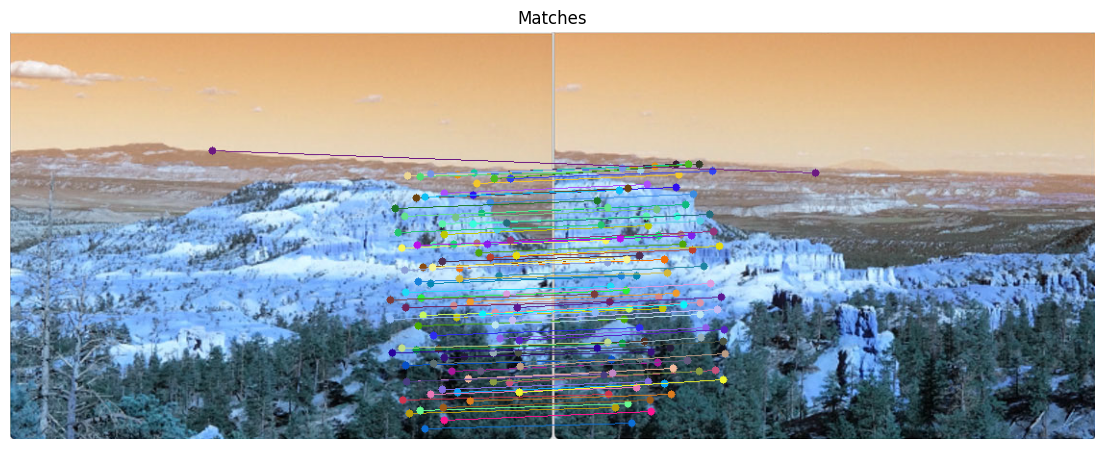

In [505]:
visualMatches(image1, image2, keypoints1, keypoints2, matches)

## 5. RANSAC

In [506]:
if len(matches) < 3:
    raise RuntimeError("Not enough matches :( RANSAC not possible)")

In [507]:
def affineLeastSquares(sourcePoints, destinationPoints):
    """
    x' = a*x + b*y + tx
    y' = c*x + d*y + ty
    """
    n = sourcePoints.shape[0]
    if n < 3:
        raise ValueError("Need at least 3 points to estimate affine transform")

    A = []
    B = []

    for i in range(n):
        x, y = sourcePoints[i]
        xp, yp = destinationPoints[i]

        A.append([x, y, 1, 0, 0, 0])
        A.append([0, 0, 0, x, y, 1])

        B.append(xp)
        B.append(yp)

    A = np.array(A, dtype=np.float32)
    B = np.array(B, dtype=np.float32)

    params, _, _, _ = np.linalg.lstsq(A, B, rcond=None)

    M = np.array([
        [params[0], params[1], params[2]],
        [params[3], params[4], params[5]],
        [0, 0, 1]
    ], dtype=np.float32)

    return M

In [508]:
def applyAffine(M, pts):
    ones = np.ones((len(pts), 1))
    homo = np.hstack([pts, ones])
    transformed = (M @ homo.T).T
    return transformed[:, :2]

In [509]:
def ransac_affine(kps1, kps2, matches, n_iter=1000, threshold=5.0, n_sample=4):
    if len(matches) < n_sample:
        return None, np.zeros(len(matches), dtype=bool)

    #keypoints --> (x,y)
    pts1 = np.array([(kps1[m[0]][1], kps1[m[0]][0]) for m in matches], dtype=np.float64)
    pts2 = np.array([(kps2[m[1]][1], kps2[m[1]][0]) for m in matches], dtype=np.float64)

    best_M = None
    best_inliers = np.zeros(len(matches), dtype=bool)
    best_n_inliers = 0

    rng = np.random.default_rng(42)

    for _ in range(n_iter):
        idx = rng.choice(len(matches), n_sample, replace=False)
        try:
            M = affineLeastSquares(pts2[idx], pts1[idx])
        except Exception:
            continue

        #Transform all pts2 then measure distance to pts1
        projected = applyAffine(M, pts2)
        residuals = np.linalg.norm(projected - pts1, axis=1)
        inliers = residuals < threshold

        n_in = inliers.sum()
        if n_in > best_n_inliers:
            best_n_inliers = n_in
            best_inliers = inliers.copy()
            best_M = M

    # Refit on all inliers for a better estimate
    if best_n_inliers >= n_sample:
        try:
            best_M = affineLeastSquares(pts2[best_inliers], pts1[best_inliers])
        except Exception:
            pass

    return best_M, best_inliers

In [510]:
M, inlier_mask = ransac_affine(keypoints1, keypoints2, matches)
n_in = int(inlier_mask.sum())
n_out = int((~inlier_mask).sum())
print(f"    Inliers: {n_in}  Outliers: {n_out}")

if M is None:
    raise ValueError("Ransac Fail")

    Inliers: 87  Outliers: 113


In [511]:
# Residuals for inliers
inlier_matches = [m for m, f in zip(matches, inlier_mask) if f]
pts1_in = np.array([(keypoints1[m[0]][1], keypoints1[m[0]][0]) for m in inlier_matches])
pts2_in = np.array([(keypoints2[m[1]][1], keypoints2[m[1]][0]) for m in inlier_matches])
proj = applyAffine(M, pts2_in)
residuals = np.linalg.norm(proj - pts1_in, axis=1)
avg_residual = float(np.mean(residuals))
print(f"Average inlier residual: {avg_residual:.3f} px")
print(f"Estimated transform:\n{M}")

Average inlier residual: 1.396 px
Estimated transform:
[[ 9.9793923e-01  3.5134505e-02  5.4294286e+00]
 [-1.5700916e-02  9.9898231e-01  3.5561624e+02]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00]]


Visual of only inlier matches

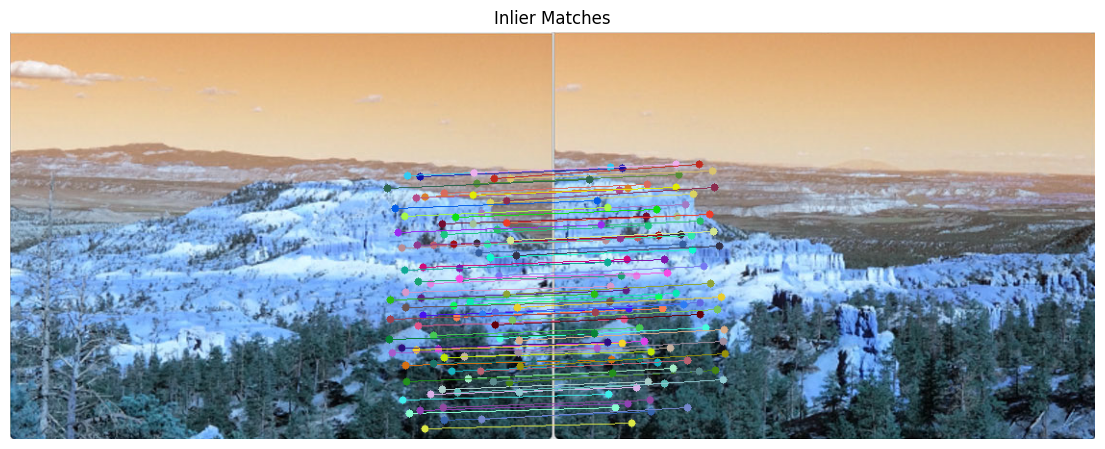

In [512]:
visualMatches(image1, image2, keypoints1, keypoints2, inlier_matches, max_show=100, title="Inlier Matches")

## 6. Warp

In [513]:
def transformPoints(M, pts):
    """
    Apply 3x3 affine matrix to Nx2 points.
    """
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1), dtype=np.float32)])
    transformed = (M @ pts_h.T).T
    return transformed[:, :2]

In [514]:
def warpStitch(img1, img2, M):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    corners2 = np.array([
        [0, 0],
        [w2 - 1, 0],
        [w2 - 1, h2 - 1],
        [0, h2 - 1]
    ], dtype=np.float32)

    corners1 = np.array([
        [0, 0],
        [w1 - 1, 0],
        [w1 - 1, h1 - 1],
        [0, h1 - 1]
    ], dtype=np.float32)

    warped_corners2 = transformPoints(M, corners2)

    all_corners = np.vstack([corners1, warped_corners2])

    min_x = np.floor(np.min(all_corners[:, 0])).astype(int)
    min_y = np.floor(np.min(all_corners[:, 1])).astype(int)
    max_x = np.ceil(np.max(all_corners[:, 0])).astype(int)
    max_y = np.ceil(np.max(all_corners[:, 1])).astype(int)

    out_w = max_x - min_x + 1
    out_h = max_y - min_y + 1

    translation = np.array([
        [1, 0, -min_x],
        [0, 1, -min_y],
        [0, 0, 1]
    ], dtype=np.float32)

    M_total = translation @ M

    warped_img2 = cv2.warpPerspective(
        cv2.cvtColor(img2, cv2.COLOR_RGB2BGR),
        M_total,
        (out_w, out_h)
    )
    warped_img2 = cv2.cvtColor(warped_img2, cv2.COLOR_BGR2RGB)

    panorama = np.zeros((out_h, out_w, 3), dtype=np.uint8)
    panorama[:] = warped_img2

    x_offset = -min_x
    y_offset = -min_y

    roi = panorama[y_offset:y_offset + h1, x_offset:x_offset + w1]

    mask_img1 = np.any(img1 > 0, axis=2)
    mask_roi = np.any(roi > 0, axis=2)

    # Simple blending:
    # where only img1 exists -> use img1
    # where only warped img2 exists -> keep warped img2
    # where both exist -> average
    both = mask_img1 & mask_roi
    only_img1 = mask_img1 & (~mask_roi)

    roi[only_img1] = img1[only_img1]
    roi[both] = ((roi[both].astype(np.float32) + img1[both].astype(np.float32)) / 2).astype(np.uint8)

    panorama[y_offset:y_offset + h1, x_offset:x_offset + w1] = roi

    return panorama

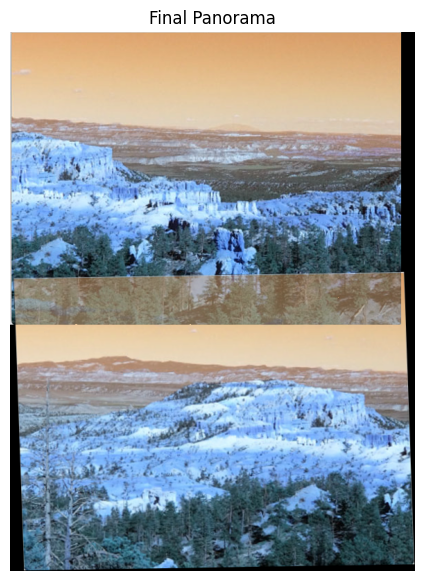

In [ ]:
panorama = warpStitch(image1, image2, M)

plt.figure(figsize=(14, 7))
plt.imshow(panorama)
plt.title("Final Panorama")
plt.axis("off")
plt.show()